# Homework 4: K-Nearest Neighbors and Cross-Validation
**Name:** Aragya Goyal | 
**Student ID:** 4541458 | 
**D value:** 58 

In [54]:
# Import Packages
import scipy.io
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Define Globals
D = 58

### Question 1: Implementing K-Fold Cross-Validation
#### Part A: Loading and Understand the Data

In [55]:
# Load the dataset
data = scipy.io.loadmat('./input/hw3_data2.mat')
X = data['X']
y = data['y']

# Report dimensions of X and y
print("Dimensions of X:", X.shape)
print("Dimensions of y:", y.shape)
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

# Report number of unique classes in y
unique_classes = np.unique(y)
print("Unique classes in y:", unique_classes)

# Report the class distribution
for c in unique_classes:
    count = np.sum(y == c)
    print(f"Class {c}: {count} samples")


Dimensions of X: (150, 4)
Dimensions of y: (150, 1)
Number of samples: 150
Number of features: 4
Unique classes in y: [1 2 3]
Class 1: 50 samples
Class 2: 50 samples
Class 3: 50 samples


**Text Response:**
1. What these numbers tell me about the dataset is that we have three different classes that are all equally represented with 50 samples of each in the dataset. The feature set is also made of 4 different features.
2. The dataset is balanced across the three different classes.

#### Part B: Implementing K-Fold Split Function

In [56]:
def create_k_folds(n_samples, k, random_seed):
    # Set random seed
    np.random.seed(random_seed)

    # Shuffle the indices
    indices = np.random.permutation(n_samples)

    # Split into k folds
    fold_size = n_samples // k
    remainder = n_samples % k

    folds = []
    start = 0
    for i in range(k):  # Loop over the folds
        end = start + fold_size
        if (i < remainder):
            end += 1
        folds.append(indices[start:end])
        start = end

    return folds

# Verify the function
# Call the function
folds = create_k_folds(X.shape[0], k=5, random_seed=D)
# Print number of indices in each fold
for i in range(len(folds)):
    print(f"Fold {i + 1}: {len(folds[i])} samples")
print(f"Total: {sum(len(fold) for fold in folds)} samples")

Fold 1: 30 samples
Fold 2: 30 samples
Fold 3: 30 samples
Fold 4: 30 samples
Fold 5: 30 samples
Total: 150 samples


#### Part C: Implementing Cross-Validation Evaluation

In [57]:
def cross_validate_knn(X, y, k_neighbors, k_folds, fold_indices):
    fold_accuracies = []
    
    # Split X and y into the k folds using fold_indices
    for i in range(k_folds):
        # Test index is the i-th fold
        test_indices = fold_indices[i]

        # Train indices are all other indices
        train_indices = np.hstack([fold_indices[j] for j in range(k_folds) if j != i])

        # Slice X and y into training and testing sets
        X_train, y_train = X[train_indices], y[train_indices]
        X_test, y_test = X[test_indices], y[test_indices]

        # Create the KNN classifier
        knn = KNeighborsClassifier(k_neighbors)
        # Train the classifier
        knn.fit(X_train, y_train)
        # Predict on the test set
        predictions = knn.predict(X_test)

        # Calculate accuracy
        accuracy = np.sum(predictions == y_test) / len(y_test)
        fold_accuracies.append(accuracy) 

    # Calculate the average accuracy
    avg_accuracy = np.mean(fold_accuracies)

    return avg_accuracy, fold_accuracies

# Run cross validation for k = 5 and k_neighbors = 3
k_neighbors = 3
k_folds = 5
avg_accuracy, fold_accuracies = cross_validate_knn(X, y.ravel(), k_neighbors, k_folds, folds)

# Report accuracy for each fold and the average accuracy
for i in range(k_folds):
    print(f"Fold {i + 1} Accuracy: {fold_accuracies[i]}")
print(f"Average Accuracy: {avg_accuracy}")

Fold 1 Accuracy: 0.9333333333333333
Fold 2 Accuracy: 1.0
Fold 3 Accuracy: 1.0
Fold 4 Accuracy: 0.9333333333333333
Fold 5 Accuracy: 0.9
Average Accuracy: 0.9533333333333335


**Text response:**
1. The accuracies for each of the folds and the average accuracy were as follows: 
- Fold 1 Accuracy: 93.3%
- Fold 2 Accuracy: 100%
- Fold 3 Accuracy: 100%
- Fold 4 Accuracy: 93.3%
- Fold 5 Accuracy: 90%
- Average Accuracy: 95.3%

2. The variance across the folds is relatively small with a maximum difference being around 10%. This might be caused to the random shuffling which may cause for some borderline samples to be in the testing dataset of some folds while other ones get easier testing samples. Also with a k-value of 3, the model might be sensitive to the local neighborhood, so if we test a borderline sample, and it happens to be around training samples that are from the other class, the prediction may be incorrect.

### Question 2: Effect of K on KNN performance
#### Part A: Systematic K Study

k = 1: Average Accuracy = 0.9466666666666667, Standard Deviation = 0.03399346342395189
k = 3: Average Accuracy = 0.9533333333333335, Standard Deviation = 0.039999999999999994
k = 5: Average Accuracy = 0.9666666666666668, Standard Deviation = 0.029814239699997188
k = 7: Average Accuracy = 0.9666666666666668, Standard Deviation = 0.029814239699997188
k = 9: Average Accuracy = 0.9600000000000002, Standard Deviation = 0.038873012632301994
k = 11: Average Accuracy = 0.9600000000000002, Standard Deviation = 0.038873012632301994
k = 13: Average Accuracy = 0.9533333333333335, Standard Deviation = 0.039999999999999994
k = 15: Average Accuracy = 0.9466666666666667, Standard Deviation = 0.03399346342395189
k = 23: Average Accuracy = 0.9400000000000002, Standard Deviation = 0.044221663871405324


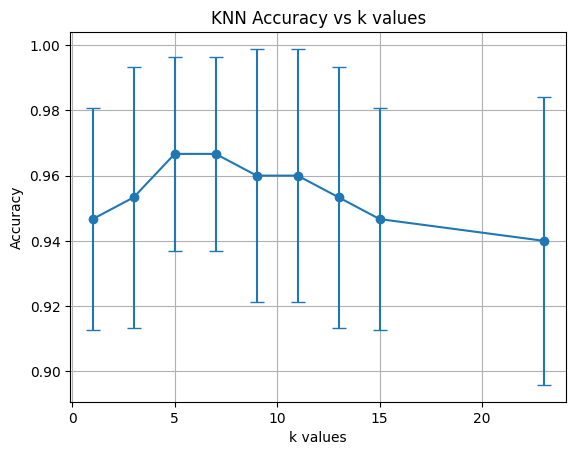

In [58]:
# Set up values of k to test
k_values = np.arange(1, 16, 2)
k_values = np.append(k_values, 15 + D % 10)

# Run cross validation for each k, store accuracy and standard deviation across folds
k_accuracies = []
k_std_devs = []
for k in k_values:
    avg_accuracy, fold_accuracies = cross_validate_knn(X, y.ravel(), k, k_folds, folds)
    k_accuracies.append(avg_accuracy)
    k_std_devs.append(np.std(fold_accuracies))
    print(f"k = {k}: Average Accuracy = {avg_accuracy}, Standard Deviation = {np.std(fold_accuracies)}")

# Plot the results
plt.errorbar(k_values, k_accuracies, yerr=k_std_devs, capsize=5, marker='o')
plt.xlabel('k values')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k values')
plt.grid()
plt.savefig('./output/ps4-2-a.png')
plt.show()

**Text Response:**
1. The values of k that give the best average accuracy are k = 5 and k = 7.
2. The value of k that give the most consistent results would also be k = 5 and k = 7.
3. Yes these are the same k.

#### Part B: Bias-Variance Tradeoff Analysis
**Text Response:**
1. As k increases from 1 to larger values, the decision boundary becomes simpler which may cause the model to underfit.
2. K = 1 may lead to overfitting because each prediction will be based off of the single closest neighbor to the test point. For example, suppose we have a region that is mostly A samples but we have one outlier from a B sample in this region. When we get a test point within this region, ideally we would want it to be classified into the A class. But due to the closest neighbor being a sample from the B class, this test point would be classified incorrectly into the B class.
3. A very large k value may lead underfitting because in the case where k = total training samples, every single prediction would consider the entire dataset. The majority vote would then just become which class has the most samples overall. This would mean that no matter where a point is located, the prediction outcome would always be the majority class.
4. The curve I observe is similar to what I described. At low k values like k=1, we see a lower accuracy than the middle of the curve due to overfitting. However, as we keep increasing k, the accuracy starts to decrease again due to underfitting.

#### Part C: Effect of Training Set Size

In [59]:
# Create 50% dataset
indices_50 = np.random.choice(X.shape[0], int(X.shape[0] * 0.5), replace=False)
X_50, y_50 = X[indices_50], y[indices_50]

# Create 25% dataset
indices_25 = np.random.choice(X.shape[0], int(X.shape[0] * 0.25), replace=False)
X_25, y_25 = X[indices_25], y[indices_25]

# Find optimal k and respective accuracies for all datasets
datasets = [(X, y, '100%'), (X_50, y_50, '50%'), (X_25, y_25, '25%')]
k_values = np.arange(1, 10, 2)
optimal_k_values = []
k_accuracies = []
for X_temp, y_temp, label in datasets:
    folds_temp = create_k_folds(X_temp.shape[0], k_folds, D)
    accuracies = []
    for k in k_values:
        avg_accuracy, _ = cross_validate_knn(X_temp, y_temp.ravel(), k, k_folds, folds_temp)
        accuracies.append(avg_accuracy)
    optimal_k = k_values[np.argmax(accuracies)]
    optimal_k_values.append(optimal_k)
    k_accuracies.append(max(accuracies))

# Create table summarizing results
print("Dataset Size | Optimal k | Accuracy")
for i in range(len(datasets)):
    print(f"{datasets[i][2]:>12} | {optimal_k_values[i]:>9} | {k_accuracies[i]}")




Dataset Size | Optimal k | Accuracy
        100% |         5 | 0.9666666666666668
         50% |         5 | 0.9600000000000002
         25% |         1 | 0.95


**Text Response:**
1. The optimal k does change as the dataset size changes. 
2. This likely happens because as your number of training samples decreases, the k value we were using previously likely becomes too big for the dataset space and causes underfitting of the model with respect to the new reduced dataset size.

### Question 3: Implementing Weighted KNN
#### Part A: Understanding Weighted KNN
**Text Response:**
1. If $\sigma$ is very small, then the exponent term becomes a very large negative number. This would then mean that the weights would be very small with only close neighbors having meaningful influence.
2. If $\sigma$ is very large, the the exponent term becomes a very small number almost approaching zero. When this happens, then the weights will all aproximately equal 1. This would mean that all neighbors would contribute equally which would be similar to unweighted KNN.

#### Part B: Implementing Weighted KNN

In [60]:
def weighted_knn(X_train, y_train, X_test, sigma):
    # Calculate distances
    distances =scipy.spatial.distance.cdist(X_test, X_train)

    # Calculate weights
    weights = np.exp(-distances**2 / (2 * sigma**2))

    # Per test sample
    classes = np.unique(y_train)
    y_pred = np.zeros(X_test.shape[0])
    for i in range(X_test.shape[0]):
        class_weights = {}
        for c in classes:
            class_weights[c] = np.sum(weights[i, y_train == c])
        y_pred[i] = max(class_weights, key=class_weights.get)

    return y_pred

#### Part C: Verifying your implementation

In [61]:
# Split data 80/20
np.random.seed(D)
indices = np.random.permutation(X.shape[0])
split = int(0.8 * X.shape[0])
X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

# Run weighted KNN
sigma = 1
y_pred = weighted_knn(X_train, y_train.ravel(), X_test, sigma)

# Calculate accuracy
accuracy = np.sum(y_pred == y_test.ravel()) / len(y_test)
print(f"Weighted KNN Accuracy: {accuracy * 100}%")

# Compare with library KNN
knn = KNeighborsClassifier(weights='distance')
knn.fit(X_train, y_train.ravel())
y_pred_lib = knn.predict(X_test)
accuracy_lib = np.sum(y_pred_lib == y_test.ravel()) / len(y_test)
print(f"Library KNN Accuracy: {accuracy_lib * 100}%")

Weighted KNN Accuracy: 83.33333333333334%
Library KNN Accuracy: 93.33333333333333%


**Text Response:**
1. My weighted KNN accuracy was 83.3% while the library function KNN's accuracy was 93.3%.
2. The accuracies here differ by 10% with the library function model achieving a higher accuracy. This might be because of the methodology of weighting. By doing guassian weighting, further points have a much smaller effect in comparison to when inverse distance weighting is used.

### Question 4: Effect of Bandwidth ($\sigma$) on Weighted KNN
#### Part A: Systematic $\sigma$ Study

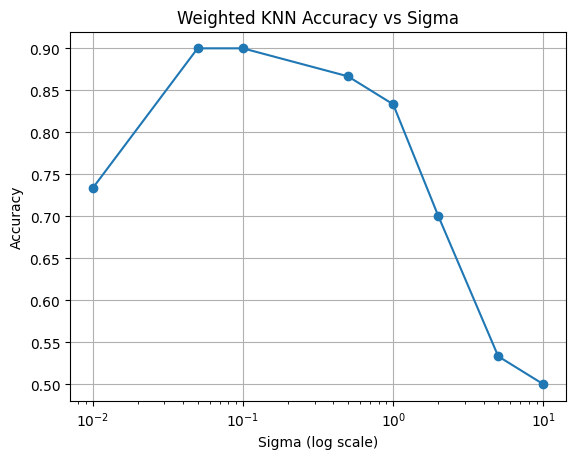

In [62]:
sigma = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
accuracies = []

# Weighted KNN for each sigma
for s in sigma:
    y_pred = weighted_knn(X_train, y_train.ravel(), X_test, s)
    accuracy = np.sum(y_pred == y_test.ravel()) / len(y_test)
    accuracies.append(accuracy)

# Plot the results
plt.plot(sigma, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('Sigma (log scale)')
plt.ylabel('Accuracy')
plt.title('Weighted KNN Accuracy vs Sigma')
plt.grid()
plt.savefig('./output/ps4-4-a.png')
plt.show()

**Text Response:**
1. The sigma that gives us the best accuracy through our testing is either 0.05 or 0.1.
2. As sigma increases, the early part of the graph sees an increase in the accuracy. However, after a value of 0.1, we see the accuracy decrease.
3. With respect to question 3, part a, this follows a similar pattern I described. At very small $\sigma$ values, the accuracy is low because the weighting is too aggressive causing overfitting since only the very close points have any meaningful weight. And as sigma increases, the accuracy decreases again because it starts to underfit. This is because all points have equal weighting which almost makes it behave like a unweighted KNN.

#### Part B: Connecting $\sigma$ to K
**Text Response:**
1. When $\sigma$ is very small, then weighted KNN behaves similarly to having a k value of 1 in the standard KNN. Both of these scenarios lead to the model overfitting because a low value of sigma causes only local values to have a weightage while a value of k=1 means that the model predicts based on only the closest neighbor which are pretty much the same situations.
2. When $\sigma$ is very large, the classifier starts to underfit.
3. For this dataset, I would likely pick the standard KNN with optimal K because even at one std. dev. away from the average accuracy, the accuracy of the standard KNN was greater than the weighted KNN with optimal $\sigma$.